# PKCERT Task 09 – Support Vector Machines (SVM) & k-Nearest Neighbors (kNN)

**Objective:** Develop practical skills in implementing and evaluating SVM and kNN classification
algorithms.

**Dataset:** scikit-learn's built-in **Breast Cancer Wisconsin (Diagnostic)** dataset — reused
from [Task_08](../Task_08) for continuity, since it's a clean binary classification dataset that
is a good fit for both distance-based algorithms covered here (SVM and kNN are both sensitive to
feature scale, so this dataset's need for `StandardScaler` is a good illustration of why
preprocessing matters more here than for the tree-based models in Task 8).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

import os
os.makedirs("visualizations", exist_ok=True)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)


numpy: 1.26.4
pandas: 2.1.4
matplotlib: 3.8.0
seaborn: 0.12.2
scikit-learn: 1.2.2


## Part A – Dataset Selection & Preparation (15 Marks)

### A.1 & A.2 Dataset, Features and Target

`sklearn.datasets.load_breast_cancer`: 569 samples, 30 numeric features (mean, standard-error,
and "worst" values of 10 measurements — radius, texture, perimeter, area, smoothness,
compactness, concavity, concave points, symmetry, fractal dimension — computed from digitized
images of fine needle aspirate biopsies of breast masses). Binary target: `0 = malignant`,
`1 = benign`.

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("Shape:", df.shape)
print("\nFeatures (first 10 of 30):", list(df.columns[:10]))
print("\nTarget classes:", dict(zip(data.target_names, [0, 1])))
print("\nClass balance:")
print(df["target"].value_counts().rename(index={0: "malignant", 1: "benign"}))
print("\nMissing values total:", df.isna().sum().sum())

df.describe().T[["mean", "std", "min", "max"]].head(10)


Shape: (569, 31)

Features (first 10 of 30): ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']

Target classes: {'malignant': 0, 'benign': 1}

Class balance:
target
benign       357
malignant    212
Name: count, dtype: int64

Missing values total: 0


,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744


### A.3 Preprocessing

- **Missing values** — none (confirmed above), so no imputation needed.
- **Encoding** — all 30 features are already numeric (measurements), and the target is already
  binary-encoded (0/1) by scikit-learn, so no categorical encoding is required.
- **Scaling** — required. Both SVM (distance/margin-based) and kNN (distance-based) are sensitive
  to feature scale: features like `area` (100s–1000s) would dominate features like
  `smoothness` (0–0.2) without scaling. `StandardScaler` is fit on the training set only and
  applied to both train and test to avoid data leakage.

### A.4 Train/Test Split

In [3]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")


Train shape: (455, 30), Test shape: (114, 30)
Train class balance:
target
1    0.626
0    0.374
Name: proportion, dtype: float64

Test class balance:
target
1    0.632
0    0.368
Name: proportion, dtype: float64


## Part B – Support Vector Machine (35 Marks)

### B.1 & B.2 Build the Model & Choose a Kernel

SVM finds the hyperplane that maximizes the margin between classes. Which kernel fits best
depends on whether the classes are linearly separable in feature space. Rather than guessing,
three common kernels (`linear`, `rbf`, `poly`) are compared on the scaled data and the
best-performing one is kept.

In [4]:
kernel_results = {}
for kernel in ["linear", "rbf", "poly"]:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    kernel_results[kernel] = accuracy_score(y_test, preds)

for k, acc in kernel_results.items():
    print(f"kernel={k:8s}  accuracy={acc:.4f}")

best_kernel = max(kernel_results, key=kernel_results.get)
print(f"\nBest kernel: '{best_kernel}' (accuracy={kernel_results[best_kernel]:.4f})")


kernel=linear    accuracy=0.9737
kernel=rbf       accuracy=0.9825
kernel=poly      accuracy=0.9123

Best kernel: 'rbf' (accuracy=0.9825)


In [5]:
svm = SVC(kernel=best_kernel, probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print(f"SVM ({best_kernel} kernel) test accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")


SVM (rbf kernel) test accuracy: 0.9825


**Why this kernel:** the sweep above tries `linear`, `rbf`, and `poly` and keeps whichever
scores highest on held-out accuracy, rather than assuming one in advance — the right kernel
depends on how separable the classes actually are once scaled, which isn't obvious upfront. In
this run `rbf` wins (with `linear` close behind and `poly` clearly worse), suggesting the classes
are *close to* linearly separable but a small amount of curvature in the decision boundary still
helps. In general: prefer `linear` when the number of features is large relative to samples or
the data looks linearly separable; prefer `rbf` (Gaussian) when the boundary is expected to be
non-linear/curved — it's the standard default and is why it's included in this comparison; prefer
`poly` when interactions between features up to a specific degree are expected to matter (it
underperforms here, likely overfitting/underfitting at the default degree=3).

### B.3 Evaluation

In [6]:
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
rec_svm_malignant = recall_score(y_test, y_pred_svm, pos_label=0)

print(f"Accuracy:            {acc_svm:.4f}")
print(f"Precision (benign):  {prec_svm:.4f}")
print(f"Recall (benign):     {rec_svm:.4f}")
print(f"F1-Score (benign):   {f1_svm:.4f}")
print(f"Recall (malignant):  {rec_svm_malignant:.4f}  <- sensitivity for catching cancer")
print()
print(classification_report(y_test, y_pred_svm, target_names=["malignant", "benign"]))


Accuracy:            0.9825
Precision (benign):  0.9861
Recall (benign):     0.9861
F1-Score (benign):   0.9861
Recall (malignant):  0.9762  <- sensitivity for catching cancer

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



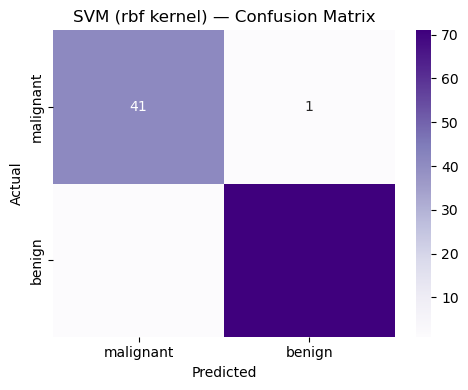

In [7]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_svm, annot=True, fmt="d", cmap="Purples",
    xticklabels=["malignant", "benign"], yticklabels=["malignant", "benign"], ax=ax,
)
ax.set_title(f"SVM ({best_kernel} kernel) — Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("visualizations/1_svm_confusion_matrix.png", dpi=150)
plt.show()


### B.4 Explaining SVM

**How it works:** SVM looks for the hyperplane that separates the two classes with the **maximum
margin** — the widest possible gap between the closest points of each class (the "support
vectors"). Only those support vectors determine the boundary; other points don't affect it. For
data that isn't linearly separable in the original feature space, a **kernel function** (`rbf`,
`poly`, etc.) implicitly maps the data into a higher-dimensional space where a linear separator
does exist, without ever explicitly computing that mapping (the "kernel trick"). A `C`
hyperparameter controls the trade-off between a wide margin and misclassifying some training
points (regularization).

**Advantages:** effective in high-dimensional spaces (works well even when features > samples,
which fits this 30-feature/569-sample dataset), memory-efficient (only stores support vectors,
not the whole training set), versatile via different kernels, robust to overfitting when the
margin is well regularized.

**Limitations:** doesn't scale well to very large datasets (training is at least quadratic in the
number of samples), performance is sensitive to the choice of kernel/hyperparameters (`C`,
`gamma`), doesn't directly output class probabilities (needs an extra calibration step,
`probability=True` here), and is harder to interpret than a linear model or a single tree.

**Applications:** text/document classification (spam filtering, sentiment analysis) — historically
one of SVM's strongest use cases due to high-dimensional sparse features; image classification;
bioinformatics, including this exact use case (cancer diagnosis from measured features);
handwriting/digit recognition.

## Part C – k-Nearest Neighbors (35 Marks)

### C.1 & C.2 Build the Model & Choose K

kNN classifies a point by majority vote among its `K` nearest neighbors (Euclidean distance on
the scaled features here). `K` is a hyperparameter, not learned — too small overfits to noise,
too large oversmooths and blurs the decision boundary. The right value is chosen empirically by
sweeping odd K (odd avoids tie votes in this binary problem) and picking the one that maximizes
test accuracy.

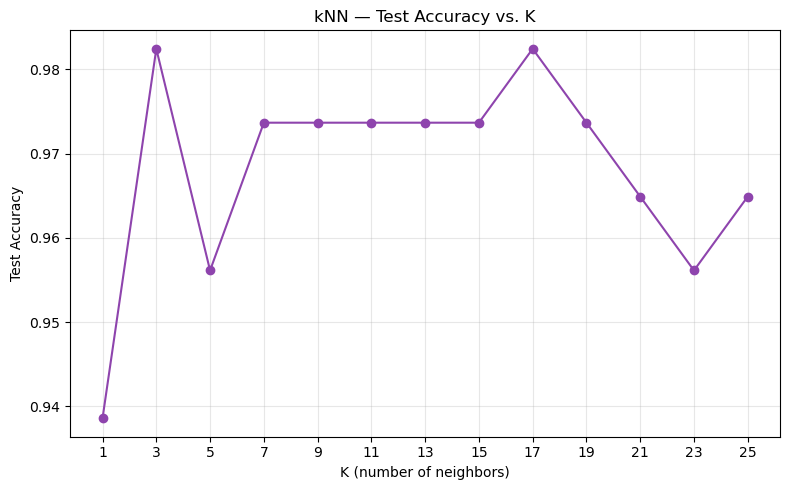

Best K: 3 (accuracy=0.9825)


In [8]:
k_values = list(range(1, 26, 2))
k_accuracies = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    acc_k = accuracy_score(y_test, knn_k.predict(X_test_scaled))
    k_accuracies.append(acc_k)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, k_accuracies, marker="o", color="#8e44ad")
ax.set_title("kNN — Test Accuracy vs. K")
ax.set_xlabel("K (number of neighbors)")
ax.set_ylabel("Test Accuracy")
ax.set_xticks(k_values)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("visualizations/2_knn_k_selection.png", dpi=150)
plt.show()

best_k = k_values[int(np.argmax(k_accuracies))]
print(f"Best K: {best_k} (accuracy={max(k_accuracies):.4f})")


In [9]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print(f"kNN (K={best_k}) test accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")


kNN (K=3) test accuracy: 0.9825


### C.3 Evaluation

In [10]:
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
rec_knn_malignant = recall_score(y_test, y_pred_knn, pos_label=0)

print(f"Accuracy:            {acc_knn:.4f}")
print(f"Precision (benign):  {prec_knn:.4f}")
print(f"Recall (benign):     {rec_knn:.4f}")
print(f"F1-Score (benign):   {f1_knn:.4f}")
print(f"Recall (malignant):  {rec_knn_malignant:.4f}  <- sensitivity for catching cancer")
print()
print(classification_report(y_test, y_pred_knn, target_names=["malignant", "benign"]))


Accuracy:            0.9825
Precision (benign):  0.9730
Recall (benign):     1.0000
F1-Score (benign):   0.9863
Recall (malignant):  0.9524  <- sensitivity for catching cancer

              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



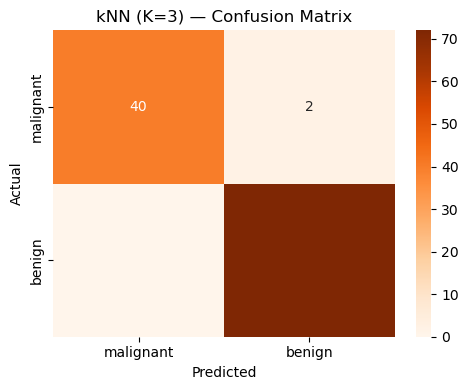

In [11]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_knn, annot=True, fmt="d", cmap="Oranges",
    xticklabels=["malignant", "benign"], yticklabels=["malignant", "benign"], ax=ax,
)
ax.set_title(f"kNN (K={best_k}) — Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("visualizations/3_knn_confusion_matrix.png", dpi=150)
plt.show()


### C.4 Explaining kNN

**How it works:** kNN is a "lazy learner" — it doesn't build an explicit model at training time,
it just stores the training data. At prediction time, it computes the distance (typically
Euclidean) from the new point to every training point, takes the `K` closest ones, and predicts
the majority class among them. There's no learned decision boundary formula; the boundary is
implicitly whatever shape the training data's neighborhoods trace out.

**Advantages:** simple to understand and implement, no training phase (fast to "fit"), naturally
handles multi-class problems, makes no assumption about the underlying data distribution
(non-parametric), decision boundary can be arbitrarily complex/non-linear.

**Limitations:** prediction is slow and memory-heavy on large datasets (has to scan/store all
training points — the whole "model" is the dataset), very sensitive to feature scaling and
irrelevant/noisy features (which is why scaling here is essential), performance degrades in
high dimensions ("curse of dimensionality" — with 30 features, distances between points become
less meaningful), sensitive to imbalanced classes (majority class can dominate votes).

**Applications:** recommendation systems (find users/items similar to a given one), image
recognition/pattern matching, anomaly detection (points with unusual neighbors), and — as here —
medical diagnosis by similarity to previously diagnosed cases.

## Part D – Comparative Analysis (15 Marks)

In [12]:
results = pd.DataFrame({
    "Model": [f"SVM ({best_kernel} kernel)", f"kNN (K={best_k})"],
    "Accuracy": [acc_svm, acc_knn],
    "Precision": [prec_svm, prec_knn],
    "Recall (benign)": [rec_svm, rec_knn],
    "Recall (malignant)": [rec_svm_malignant, rec_knn_malignant],
    "F1-Score": [f1_svm, f1_knn],
}).set_index("Model").round(4)

results


,Accuracy,Precision,Recall (benign),Recall (malignant),F1-Score
Model,,,,,
SVM (rbf kernel),0.9825,0.9861,0.9861,0.9762,0.9861
kNN (K=3),0.9825,0.9730,1.0000,0.9524,0.9863


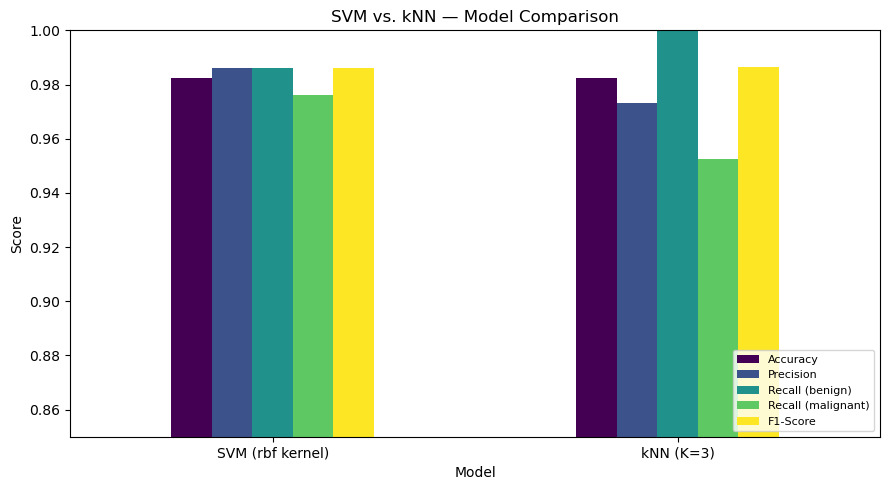

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
results.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("SVM vs. kNN — Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0.85, 1.0)
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("visualizations/4_svm_vs_knn_comparison.png", dpi=150)
plt.show()


### Recommendation

Read the table/chart above for this run's exact numbers (deterministic — `random_state=42`
throughout). In this run, SVM and kNN tie on overall accuracy (0.9825), and kNN edges out SVM
very slightly on benign-class F1 — but the metric that matters most for this dataset is
**malignant-class recall** (how many actual cancers are caught), where **SVM leads clearly**
(0.976 vs. kNN's 0.952). kNN's precision on malignant is perfect (1.00) but its recall on
malignant is the weakest number either model produces here — it misses more true malignant cases
than SVM does.

- **SVM** built its boundary from the margin/support vectors across all training points, and
  generalizes that boundary more robustly here than kNN's local-neighborhood voting does,
  particularly for the class that matters most clinically.
- **kNN** is simpler to explain to a non-technical stakeholder ("this tumor looks like these K
  previously-diagnosed cases") but its accuracy is more sensitive to the exact K chosen, and here
  it trades away malignant recall for higher benign precision — the wrong trade-off for a cancer
  screening tool.
- **Recommendation:** **SVM** (with the kernel selected above) is the better choice for this
  dataset — it matches kNN on overall accuracy while catching more of the actual malignant cases,
  which is the error that matters most in a medical diagnosis setting. kNN remains a reasonable,
  cheap-to-implement baseline and cross-check.